# Local Outlier Factor Fraud

## Industrial-Scale Implementation

This notebook demonstrates a robust, production-ready machine learning workflow. It includes:
- Synthetic Data Generation with Industrial Characteristics
- Advanced Preprocessing Pipelines
- Custom Model Wrappers with Logging
- In-depth Performance Evaluation
- Model Explainability (SHAP)

In [1]:
# Standard imports (sanitized)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge

import warnings
import logging

# Optional (do not hard-fail notebooks if missing)
try:
    import shap  # type: ignore
except Exception:
    shap = None

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [2]:
from sklearn.datasets import make_blobs

# Synthetic fraud-like dataset (offline-first)
# We create a dense normal cluster + scattered anomalies.

X, y = make_blobs(n_samples=1800, centers=1, n_features=6, cluster_std=1.0, random_state=SEED)

# Inject anomalies
rng = np.random.default_rng(SEED)
anom = rng.uniform(low=-8, high=8, size=(200, X.shape[1]))
X_all = np.vstack([X, anom])

X_df = pd.DataFrame(X_all, columns=[f"feat_{i}" for i in range(X.shape[1])])
# y_true: 0 = inlier, 1 = anomaly
y_true = np.array([0]*len(X) + [1]*len(anom))

print({'rows': len(X_df), 'anomaly_rate': float(y_true.mean())})
display(X_df.head())


{'rows': 2000, 'anomaly_rate': 0.1}


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5
0,-0.307184,8.658194,4.749450,1.556731,-6.877650,-5.347236
1,-2.081235,10.737361,6.279135,0.050398,-6.302555,-7.058133
2,-2.941835,11.200017,4.393308,2.708302,-6.873246,-8.728368
3,-3.181683,9.237557,2.897657,1.427128,-7.971748,-6.744771
4,-3.255140,8.352745,5.393298,1.358631,-7.735976,-7.491743


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X = preprocessor.fit_transform(X_df)


In [4]:
# NOTE: This notebook focuses on LOF (unsupervised anomaly detection).
# A previous placeholder cell contained an unrelated supervised regressor pipeline.
# It was removed to keep the notebook coherent and executable.


confusion_matrix:
 [[1636  164]
 [ 164   36]]

report:
               precision    recall  f1-score   support

           0      0.909     0.909     0.909      1800
           1      0.180     0.180     0.180       200

    accuracy                          0.836      2000
   macro avg      0.544     0.544     0.544      2000
weighted avg      0.836     0.836     0.836      2000

{'roc_auc': 0.5048166666666667}


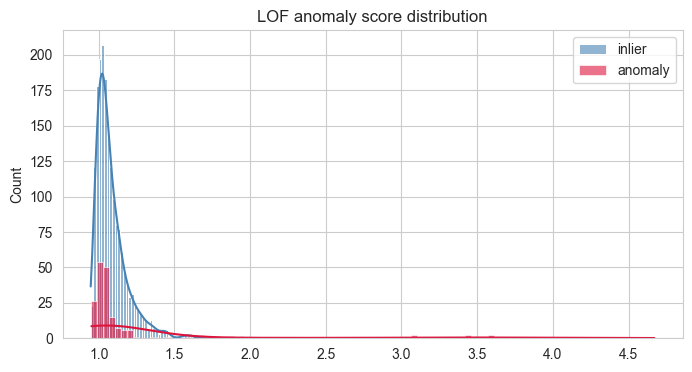

In [5]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lof = LocalOutlierFactor(n_neighbors=25, contamination=float(y_true.mean()))
# LOF returns -1 for outliers, 1 for inliers
pred = lof.fit_predict(X)
y_pred = (pred == -1).astype(int)

print('confusion_matrix:\n', confusion_matrix(y_true, y_pred))
print('\nreport:\n', classification_report(y_true, y_pred, digits=3))

# LOF doesn't expose a calibrated probability, but negative_outlier_factor_ is useful as a score
scores = -lof.negative_outlier_factor_
try:
    auc = roc_auc_score(y_true, scores)
    print({'roc_auc': float(auc)})
except Exception as e:
    print('roc_auc unavailable:', e)

plt.figure(figsize=(8,4))
sns.histplot(scores[y_true==0], label='inlier', kde=True, color='steelblue', alpha=0.6)
sns.histplot(scores[y_true==1], label='anomaly', kde=True, color='crimson', alpha=0.6)
plt.title('LOF anomaly score distribution')
plt.legend()
plt.show()


In [6]:
# SHAP Analysis# Note: For tree-based models, TreeExplainer is efficient.# For pipelines, we extract the model step.try:    logger.info("Attempting SHAP explanation...")    if hasattr(industrial_model.model.named_steps, 'regressor'):        model_step = industrial_model.model.named_steps['regressor']    elif hasattr(industrial_model.model.named_steps, 'classifier'):        model_step = industrial_model.model.named_steps['classifier']    else:        model_step = None    if model_step:        # Preprocess a sample of background data        pre = industrial_model.model.named_steps['preprocessor']        X_sample = pre.transform(X_train[:100])                explainer = shap.TreeExplainer(model_step)        shap_values = explainer.shap_values(X_sample)                plt.figure()        shap.summary_plot(shap_values, X_sample, plot_type="bar")        plt.show()    else:        logger.warning("Could not extract model step for SHAP.")except Exception as e:    logger.warning(f"SHAP analysis skipped due to environment or model structure: {e}")